In [1]:
install.packages("dplyr")
install.packages("ggplot2")
install.packages("corrplot")
install.packages("readr")

library(dplyr)
library(ggplot2)
library(corrplot)
library(readr)

unzip("northstar_dataset.zip", exdir = "northstar_dataset")

customers <- read_csv("northstar_dataset/northstar_dataset/customers.csv")
orders <- read_csv("northstar_dataset/northstar_dataset/orders.csv")
deliveries <- read_csv("northstar_dataset/northstar_dataset/deliveries.csv")
complaints <- read_csv("northstar_dataset/northstar_dataset/complaints.csv")
incidents <- read_csv("northstar_dataset/northstar_dataset/incidents.csv")
drivers <- read_csv("northstar_dataset/northstar_dataset/drivers.csv")
vehicles <- read_csv("northstar_dataset/northstar_dataset/vehicles.csv")
hubs <- read_csv("northstar_dataset/northstar_dataset/hubs.csv")
app_events <- read_csv("northstar_dataset/northstar_dataset/app_events.csv")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 

In [2]:
str(deliveries)
summary(deliveries)

str(complaints)
summary(complaints)


spc_tbl_ [950 × 13] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ delivery_id                  : chr [1:950] "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr [1:950] "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr [1:950] "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr [1:950] "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr [1:950] "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : POSIXct[1:950], format: "2024-06-18 10:57:00" "2025-01-11 18:45:00" ...
 $ delivery_completed_at        : POSIXct[1:950], format: "2024-06-19 09:05:59" "2025-01-11 17:39:00" ...
 $ delivery_status              : chr [1:950] "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num [1:950] 17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : num [1:950] 1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : num [1:950] 0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rati

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id    dispatch_time                 delivery_completed_at        
 Length   :950   Min.   :2024-01-01 03:20:00   Min.   :2024-01-01 15:35:48  
 N.unique :  8   1st Qu.:2024-06-21 17:54:00   1st Qu.:2024-06-18 14:13:03  
 N.blank  :  0   Median :2024-12-12 14:19:30   Median :2024-12-13 02:04:50  
 Min.nchar:  3   Mean   :2024-12-20 13:10:27   Mean   :2024-12-19 20:19:52  
 Max.nchar:  3   3rd Qu.:2025-06-12 01:39:15   3rd Qu.:2025-06-12 00:14:26  
                 M

spc_tbl_ [320 × 10] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ complaint_id       : chr [1:320] "CP0001" "CP0002" "CP0003" "CP0004" ...
 $ customer_id        : chr [1:320] "C0464" "C0056" "C0469" "C0631" ...
 $ order_id           : chr [1:320] "O00814" "O00628" "O00384" "O00406" ...
 $ complaint_type     : chr [1:320] "AppIssue" "MissedPickup" "Delay" "Delay" ...
 $ channel            : chr [1:320] "App" "Phone" "Chatbot" "App" ...
 $ severity           : chr [1:320] "High" "Medium" "High" "Medium" ...
 $ created_at         : POSIXct[1:320], format: "2025-03-30 02:36:00" "2024-11-07 10:05:00" ...
 $ status             : chr [1:320] "Open" "Open" "Open" "AwaitingCustomer" ...
 $ resolution_days    : num [1:320] 11 4 16 7 1 9 4 18 4 1 ...
 $ compensation_amount: num [1:320] 24 21.6 26.4 23.4 16.2 ...
 - attr(*, "spec")=
  .. cols(
  ..   complaint_id = col_character(),
  ..   customer_id = col_character(),
  ..   order_id = col_character(),
  ..   complaint_type = col_character(),
  ..  

    complaint_id    customer_id       order_id     complaint_type
 Length   :320   Length   :320   Length   :320   Length   :320   
 N.unique :320   N.unique :233   N.unique :285   N.unique :  7   
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0   
 Min.nchar:  6   Min.nchar:  5   Min.nchar:  6   Min.nchar:  5   
 Max.nchar:  6   Max.nchar:  5   Max.nchar:  6   Max.nchar: 17   
                                                                 
                                                                 
      channel         severity     created_at                        status   
 Length   :320   Length   :320   Min.   :2024-01-02 15:47:00   Length   :320  
 N.unique :  4   N.unique :  3   1st Qu.:2024-06-19 04:52:00   N.unique :  4  
 N.blank  :  0   N.blank  :  0   Median :2024-11-27 07:32:00   N.blank  :  0  
 Min.nchar:  3   Min.nchar:  3   Mean   :2024-12-06 23:30:14   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   3rd Qu.:2025-05-19 10:53:45   Max.nchar: 16 

In [3]:
colSums(is.na(deliveries))

sum(duplicated(deliveries))

colSums(is.na(complaints))

sum(duplicated(complaints))
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time)
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at)


delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                           19                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                            14 
          fuel_or_charge_cost 
                            0

[1] 0

complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                  16

[1] 0

In [4]:
summary(deliveries$route_distance_km)

summary(deliveries$manual_route_override_count)

summary(deliveries$customer_rating_post_delivery)

summary(deliveries$fuel_or_charge_cost)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.135  12.840  13.909  16.835  41.940 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  1.0000  0.9695  2.0000  7.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.360   4.040   3.865   4.550   5.000      14 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.500   9.925  12.645  12.841  15.697  29.430 

In [5]:
summary(complaints$compensation_amount)

summary(complaints$resolution_days)

table(complaints$severity)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  0.000   8.822  18.405  20.257  29.145  61.850      16 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.750   7.000   7.928  11.000  25.000 


  High    Low Medium 
    77     71    172 

In [6]:
summary(drivers$training_score)

summary(drivers$driver_rating)

summary(drivers$years_experience)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  40.60   68.55   75.20   74.91   82.75   99.00       7 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   5.000   8.500   8.224  11.750  15.000 

In [7]:
summary(vehicles$battery_health_pct)

table(vehicles$maintenance_status)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  42.00   68.20   78.05   76.79   85.78  100.00       4 


   Active  InRepair Scheduled 
       67        36        17 

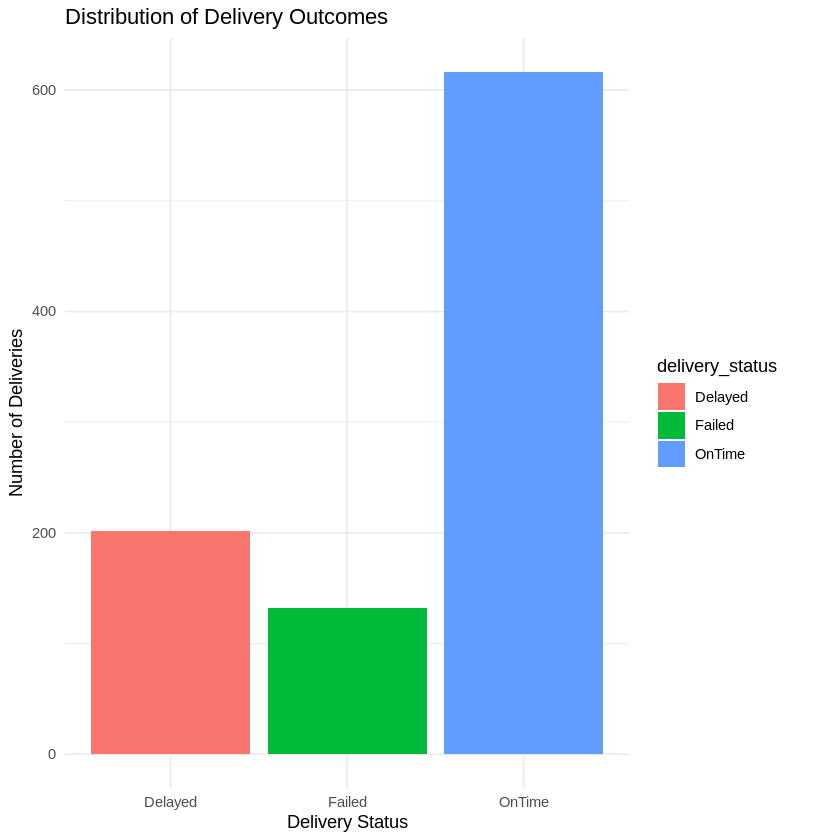

In [8]:
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
    geom_bar() +
    labs(
        title = "Distribution of Delivery Outcomes",
        x = "Delivery Status",
        y = "Number of Deliveries"
    ) +
    theme_minimal()


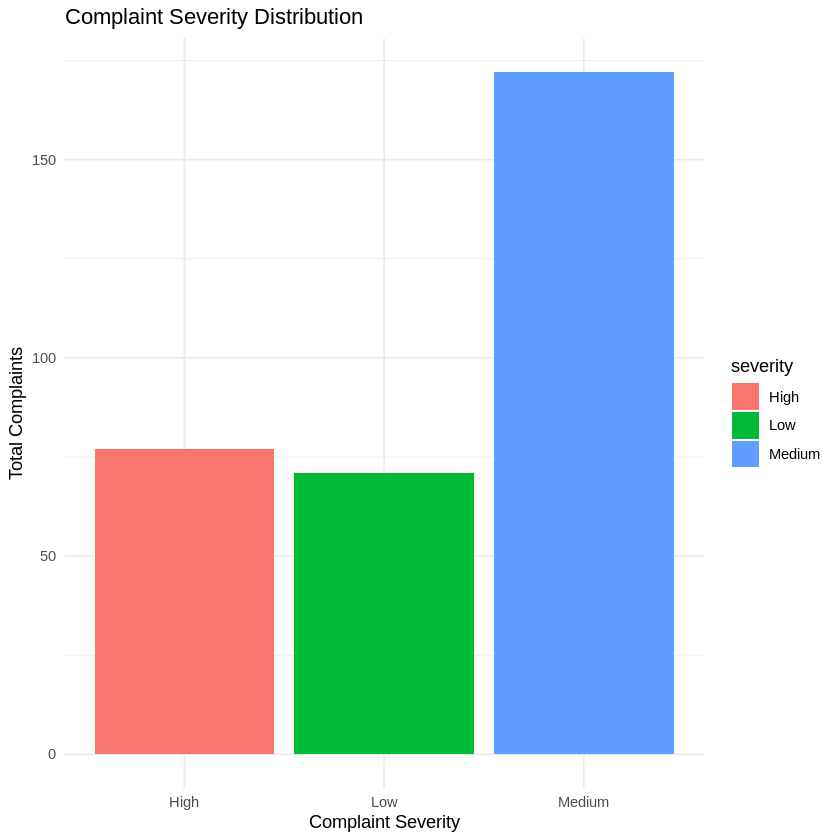

In [9]:
ggplot(complaints, aes(x = severity, fill = severity)) +
    geom_bar() +
    labs(
        title = "Complaint Severity Distribution",
        x = "Complaint Severity",
        y = "Total Complaints"
    ) +
    theme_minimal()


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


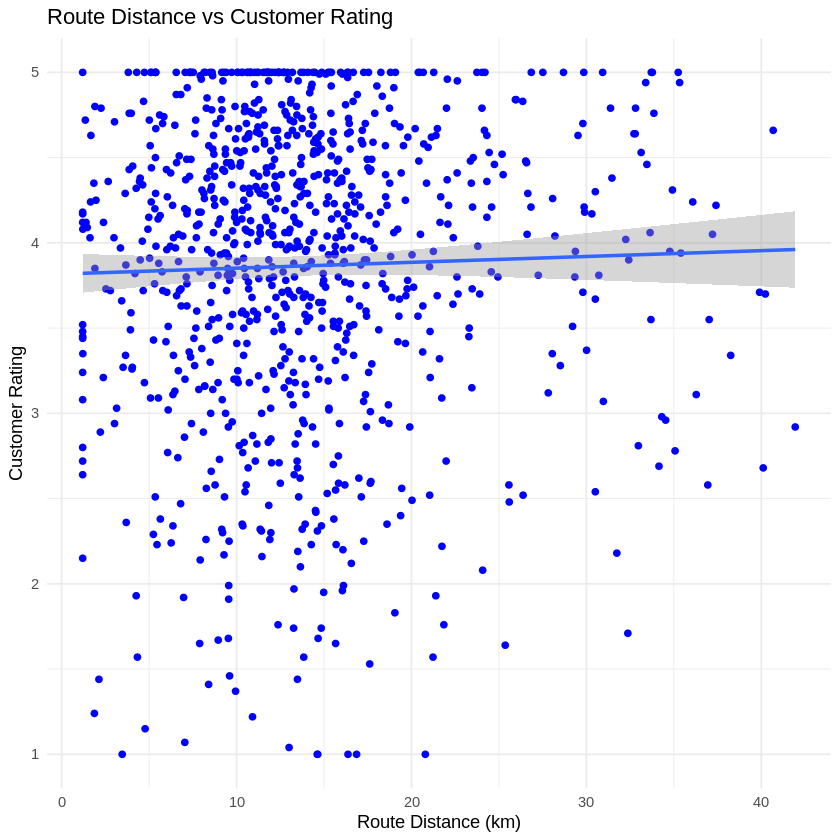

In [10]:
ggplot(deliveries, aes(
    x = route_distance_km,
    y = customer_rating_post_delivery
)) +
    geom_point(color = "blue") +
    geom_smooth(method = "lm") +
    labs(
        title = "Route Distance vs Customer Rating",
        x = "Route Distance (km)",
        y = "Customer Rating"
    ) +
    theme_minimal()


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


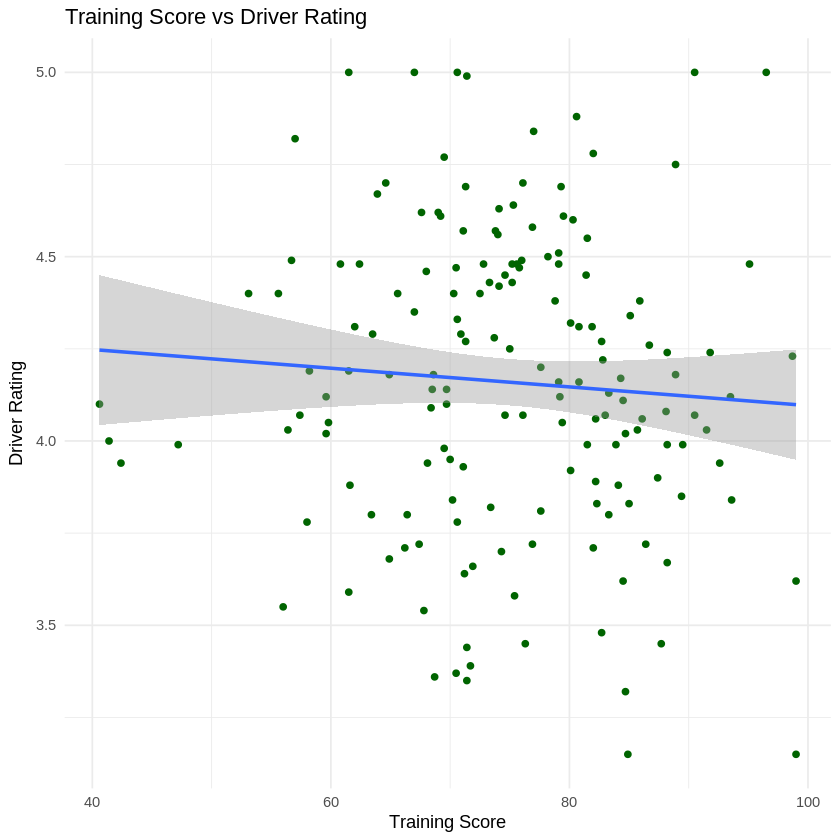

In [11]:
ggplot(drivers, aes(
    x = training_score,
    y = driver_rating
)) +
    geom_point(color = "darkgreen") +
    geom_smooth(method = "lm") +
    labs(
        title = "Training Score vs Driver Rating",
        x = "Training Score",
        y = "Driver Rating"
    ) +
    theme_minimal()


Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”


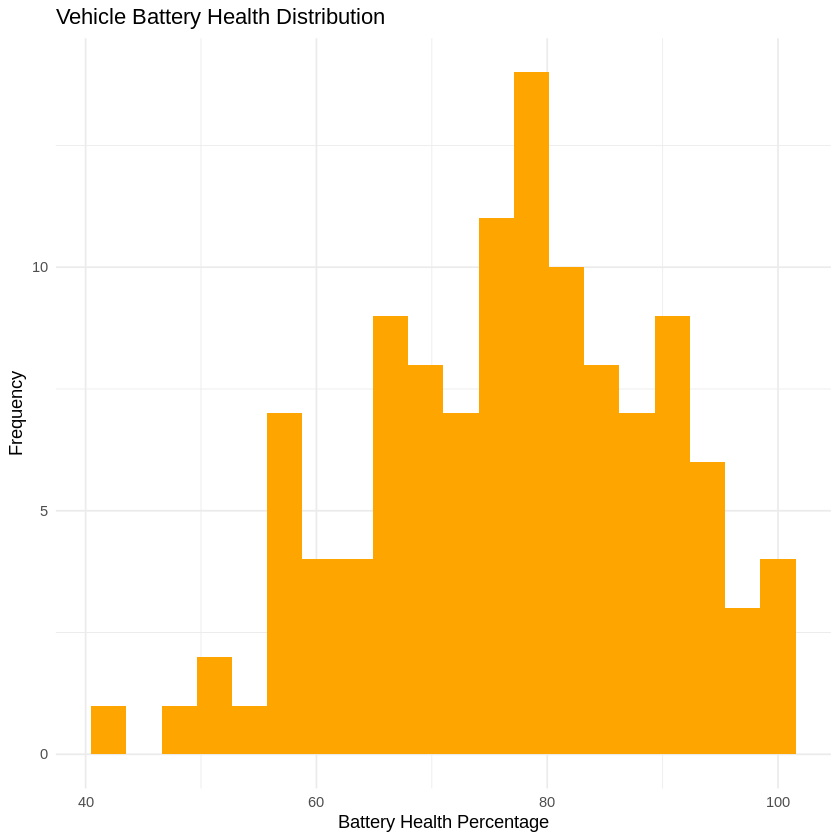

In [12]:
ggplot(vehicles, aes(x = battery_health_pct)) +
    geom_histogram(bins = 20, fill = "Orange") +
    labs(
        title = "Vehicle Battery Health Distribution",
        x = "Battery Health Percentage",
        y = "Frequency"
    ) +
    theme_minimal()


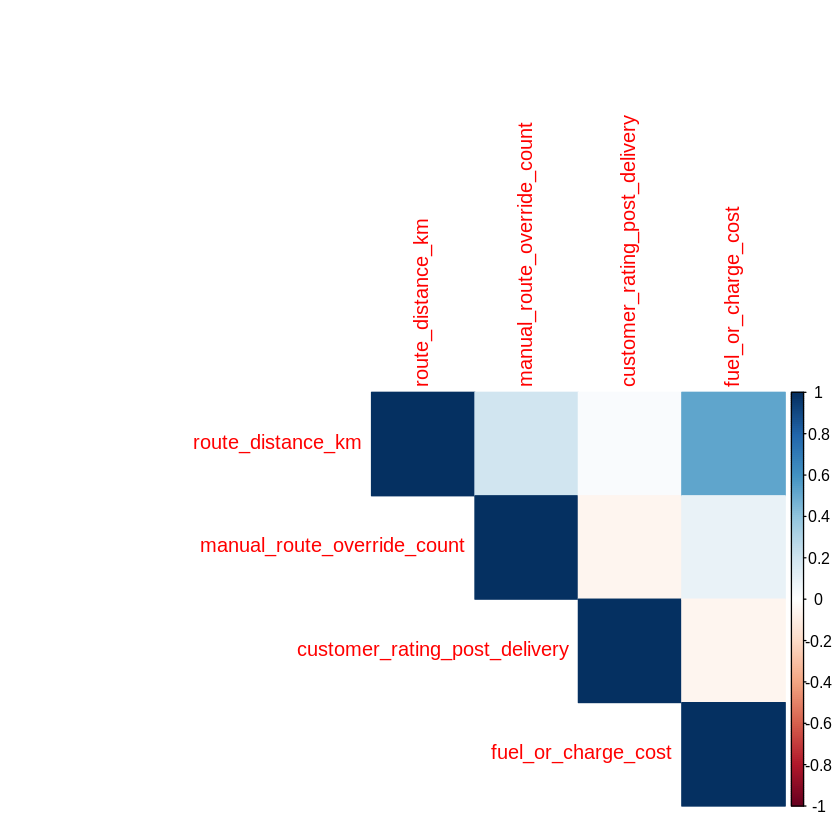

In [13]:
numeric_delivery_data <- deliveries %>%
    select(
        route_distance_km,
        manual_route_override_count,
        customer_rating_post_delivery,
        fuel_or_charge_cost
    )

correlation_matrix <- cor(
    numeric_delivery_data,
    use = "complete.obs"
)

corrplot(
    correlation_matrix,
    method = "color",
    type = "upper"
)


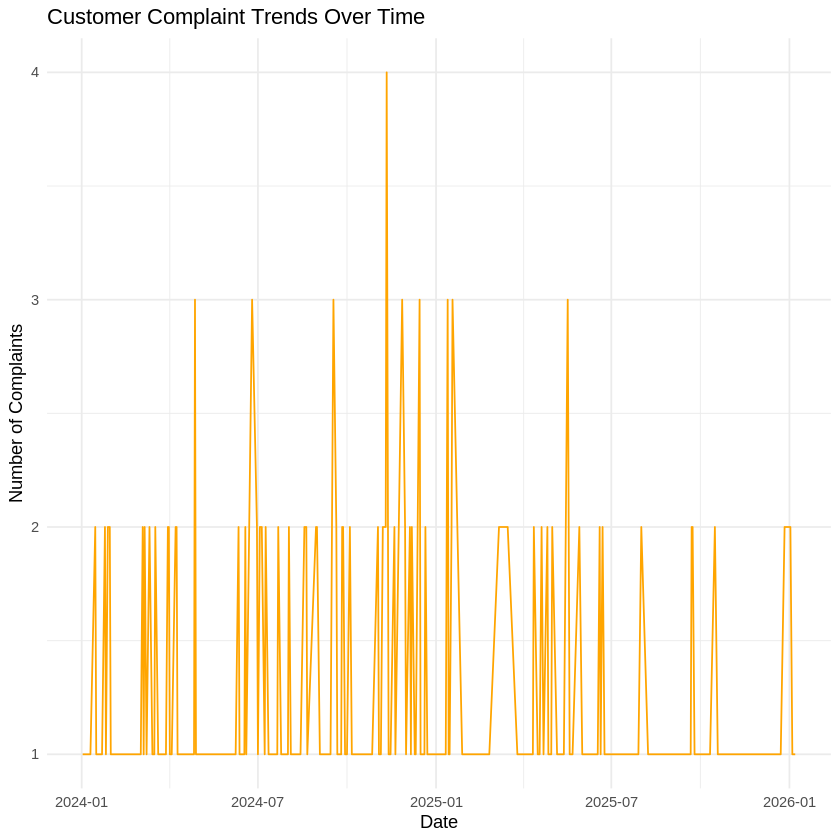

In [14]:
complaints$created_at <- as.Date(
    complaints$created_at
)

complaint_trends <- complaints %>%
    group_by(created_at) %>%
    summarise(
        total_complaints = n()
    )

ggplot(
    complaint_trends,
    aes(
        x = created_at,
        y = total_complaints
    )
) +
    geom_line(color = "Orange") +
    labs(
        title = "Customer Complaint Trends Over Time",
        x = "Date",
        y = "Number of Complaints"
    ) +
    theme_minimal()

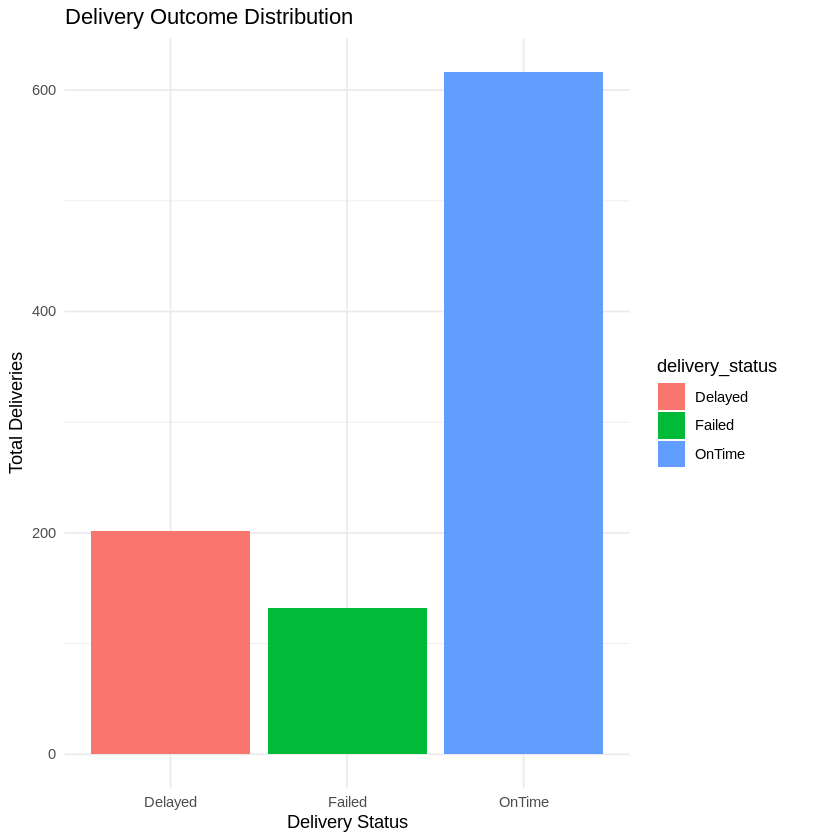

In [15]:
delivery_trends <- deliveries %>%
    group_by(delivery_status) %>%
    summarise(
        total_deliveries = n()
    )

ggplot(
    delivery_trends,
    aes(
        x = delivery_status,
        y = total_deliveries,
        fill = delivery_status
    )
) +
    geom_bar(stat = "identity") +
    labs(
        title = "Delivery Outcome Distribution",
        x = "Delivery Status",
        y = "Total Deliveries"
    ) +
    theme_minimal()


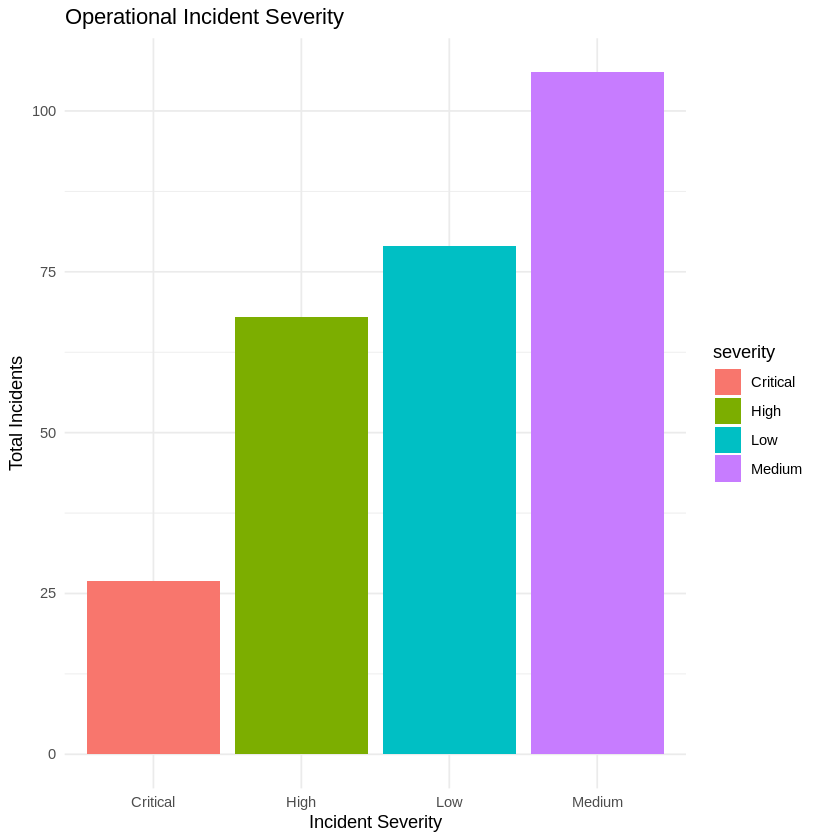

In [16]:
incident_summary <- incidents %>%
    group_by(severity) %>%
    summarise(
        total_incidents = n()
    )

ggplot(
    incident_summary,
    aes(
        x = severity,
        y = total_incidents,
        fill = severity
    )
) +
    geom_bar(stat = "identity") +
    labs(
        title = "Operational Incident Severity",
        x = "Incident Severity",
        y = "Total Incidents"
    ) +
    theme_minimal()
